# Relationship between variables

There is a popular survey called NLSY97, it has data about students taking verbal and mathematical tests, we are going to use this data for seeing that if a student good at math is also good at verbal exams too.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
stud = pd.read_csv("./data/nlsy97-extract.csv.gz").replace([-1, -2, -3, -4, -5], np.nan)

In [3]:
stud["sat_verbal"] = stud["R9793800"]
stud["sat_math"] = stud["R9793900"]

In [4]:
cols = ["sat_verbal", "sat_math"]
for c in cols:
    invalid = stud[c] < 200
    stud.loc[invalid, c] = np.nan

stud_valid = stud.dropna(subset=cols).copy()
stud_valid.shape

(1398, 36)

In [5]:
stud_valid[["sat_verbal", "sat_math"]]

,sat_verbal,sat_math
0,350.0,470.0
1,460.0,440.0
7,620.0,620.0
8,380.0,460.0
9,600.0,560.0
...,...,...
8935,300.0,310.0
8964,420.0,420.0
8969,540.0,530.0
8972,370.0,410.0


## Scatter Plots

Now that we have our columns, let's see if there is a correlation between verbal and math score.

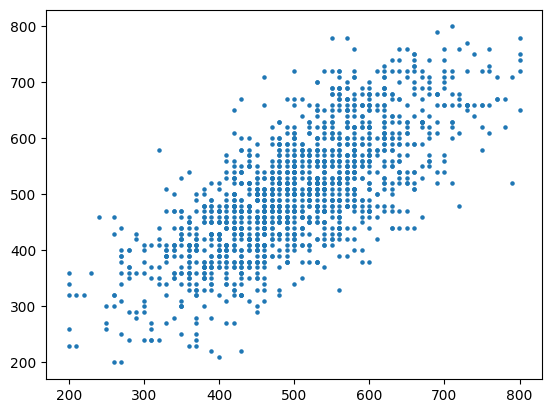

In [6]:
fig, ax = plt.subplots()
ax.scatter(stud_valid["sat_verbal"], stud_valid["sat_math"], s=5)
plt.show()

Becuase the scores are rounded of the nearest multiple of 10, we cannot bring back the data, but we can add random noise.

In [7]:
def jit(seq, std=1):
    return np.random.normal(0, std, len(seq)) + seq

In [8]:
sat_verbal_jitter = jit(stud_valid["sat_verbal"], 3)
sat_math_jitter = jit(stud_valid["sat_math"], 3)

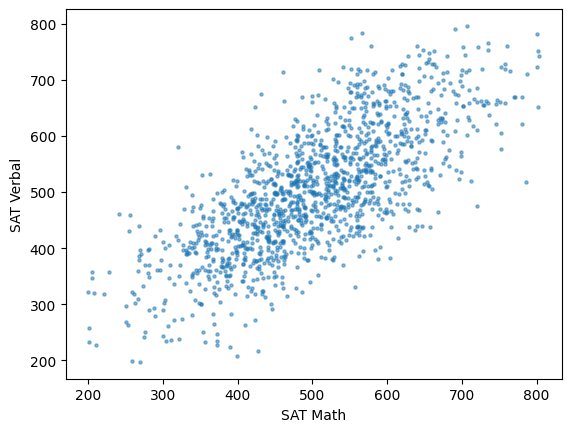

In [9]:
fig, ax = plt.subplots()
ax.scatter(sat_verbal_jitter, sat_math_jitter, s=5, alpha=0.5)
ax.set_xlabel("SAT Math")
ax.set_ylabel("SAT Verbal")
plt.show()

We can see some kind of correlation, but we had to tweak a lot of stuff to get the visualization right.

## Decile Plots

We have to divide the data to deciles, hence the name of the plot.

In [10]:
deciles = pd.qcut(stud_valid["sat_verbal"], 30, labels=False) + 1
deciles.value_counts().sort_index()

sat_verbal
1     50
2     65
3     27
4     51
5     63
6     36
7     46
8     50
9     43
10    48
11    54
12    38
13    56
14    46
15    57
16    32
17    44
18    54
19    48
20    41
21    59
22    45
23    48
24    28
25    43
26    49
27    46
28    50
29    43
30    38
Name: count, dtype: int64

In [11]:
stud_groupby = stud_valid.groupby(deciles)
math_groupby_ser = stud_groupby["sat_math"]
median = math_groupby_ser.quantile(0.5)
low = math_groupby_ser.quantile(0.1)
high = math_groupby_ser.quantile(0.9)
ixs = stud_groupby["sat_verbal"].quantile(0.5)
ixs

sat_verbal
1     270.0
2     340.0
3     360.0
4     380.0
5     390.0
6     410.0
7     420.0
8     430.0
9     440.0
10    450.0
11    460.0
12    470.0
13    480.0
14    490.0
15    500.0
16    510.0
17    520.0
18    530.0
19    540.0
20    550.0
21    560.0
22    570.0
23    580.0
24    590.0
25    600.0
26    620.0
27    630.0
28    660.0
29    690.0
30    750.0
Name: sat_verbal, dtype: float64

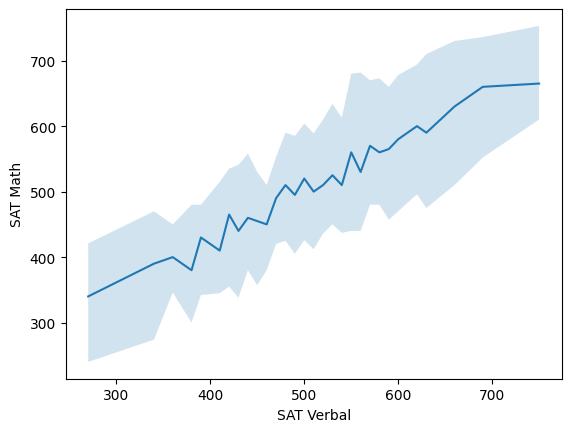

In [12]:
fig, ax = plt.subplots()
ax.fill_between(ixs, low, high, alpha=0.2)
ax.plot(ixs, median, label="median")
ax.set_xlabel("SAT Verbal")
ax.set_ylabel("SAT Math")
plt.show()

We can see that relationship between SAT Math score and SAT Verbal score of respondents are somewhat has linear correlation.

## Correlation

When NLSY respondents were in 9th grade, many of them took the math section of the PIAT. Let's see if there is a correlation between PIAT Math score and the SAT Math score.

In [13]:
stud_valid["piat_math"] = stud_valid["R1318200"]
stud_piat_sat = stud_valid.dropna(subset=["piat_math"])
stud_piat_sat.reset_index(inplace=True)
stud_piat_sat

,index,R0000100,R0490200,R0536300,R0536401,R0536402,R1235800,R1318200,R1482600,R3961900,...,S1552700,U0008900,U1845500,U3444000,U4949700,Z9083800,Z9083900,sat_verbal,sat_math,piat_math
0,1,2,NaN,1,7,1982,1,145.0,2,NaN,...,NaN,98928.0,116000.0,188857.0,180000.0,14.0,2.0,460.0,440.0,145.0
1,9,10,NaN,1,3,1984,1,93.0,4,103.0,...,NaN,NaN,175000.0,263000.0,599728.0,16.0,4.0,600.0,560.0,93.0
2,30,31,NaN,1,7,1982,1,107.0,4,NaN,...,NaN,60000.0,85200.0,110000.0,120000.0,16.0,4.0,450.0,590.0,107.0
3,40,41,NaN,2,1,1983,1,96.0,4,NaN,...,NaN,121829.0,180500.0,200000.0,255000.0,17.0,4.0,560.0,690.0,96.0
4,59,60,NaN,1,1,1984,1,77.0,4,101.0,...,77.0,NaN,NaN,150000.0,103571.0,18.0,5.0,260.0,460.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,8912,8950,NaN,2,7,1984,1,91.0,4,89.0,...,NaN,70040.0,NaN,NaN,90000.0,15.0,3.0,400.0,320.0,91.0
814,8935,8973,NaN,2,9,1982,0,80.0,2,NaN,...,NaN,NaN,NaN,NaN,NaN,16.0,2.0,300.0,310.0,80.0
815,8969,9008,NaN,2,12,1982,1,101.0,1,NaN,...,NaN,55600.0,70050.0,74000.0,59800.0,17.0,4.0,540.0,530.0,101.0
816,8972,9011,20.0,2,6,1982,1,89.0,4,NaN,...,NaN,80000.0,90300.0,NaN,95000.0,14.0,3.0,370.0,410.0,89.0


In [14]:
stud_piat_sat_pdf = (
    stud_piat_sat["piat_math"].value_counts(normalize=True).sort_index().cumsum()
)

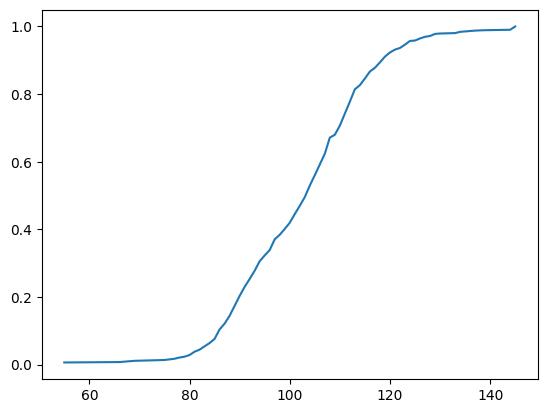

In [15]:
fig, ax = plt.subplots()
ax.plot(stud_piat_sat_pdf.index, stud_piat_sat_pdf)
plt.show()

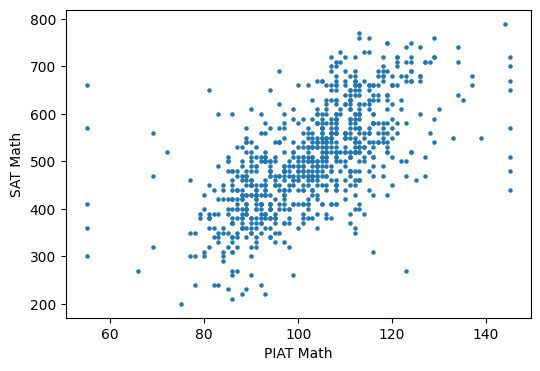

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(stud_piat_sat["piat_math"], stud_piat_sat["sat_math"], s=5)
ax.set_xlabel("PIAT Math")
ax.set_ylabel("SAT Math")
plt.show()

I just want to see if visualization would get better if I used min-max scaler for both columns

In [17]:
scaler = MinMaxScaler()
stud_piat_sat["piat_math_minmax"] = scaler.fit_transform(stud_piat_sat[["piat_math"]])
stud_piat_sat["sat_math_minmax"] = scaler.fit_transform(stud_piat_sat[["sat_math"]])
stud_piat_sat

,index,R0000100,R0490200,R0536300,R0536401,R0536402,R1235800,R1318200,R1482600,R3961900,...,U1845500,U3444000,U4949700,Z9083800,Z9083900,sat_verbal,sat_math,piat_math,piat_math_minmax,sat_math_minmax
0,1,2,NaN,1,7,1982,1,145.0,2,NaN,...,116000.0,188857.0,180000.0,14.0,2.0,460.0,440.0,145.0,1.000000,0.406780
1,9,10,NaN,1,3,1984,1,93.0,4,103.0,...,175000.0,263000.0,599728.0,16.0,4.0,600.0,560.0,93.0,0.422222,0.610169
2,30,31,NaN,1,7,1982,1,107.0,4,NaN,...,85200.0,110000.0,120000.0,16.0,4.0,450.0,590.0,107.0,0.577778,0.661017
3,40,41,NaN,2,1,1983,1,96.0,4,NaN,...,180500.0,200000.0,255000.0,17.0,4.0,560.0,690.0,96.0,0.455556,0.830508
4,59,60,NaN,1,1,1984,1,77.0,4,101.0,...,NaN,150000.0,103571.0,18.0,5.0,260.0,460.0,77.0,0.244444,0.440678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,8912,8950,NaN,2,7,1984,1,91.0,4,89.0,...,NaN,NaN,90000.0,15.0,3.0,400.0,320.0,91.0,0.400000,0.203390
814,8935,8973,NaN,2,9,1982,0,80.0,2,NaN,...,NaN,NaN,NaN,16.0,2.0,300.0,310.0,80.0,0.277778,0.186441
815,8969,9008,NaN,2,12,1982,1,101.0,1,NaN,...,70050.0,74000.0,59800.0,17.0,4.0,540.0,530.0,101.0,0.511111,0.559322
816,8972,9011,20.0,2,6,1982,1,89.0,4,NaN,...,90300.0,NaN,95000.0,14.0,3.0,370.0,410.0,89.0,0.377778,0.355932


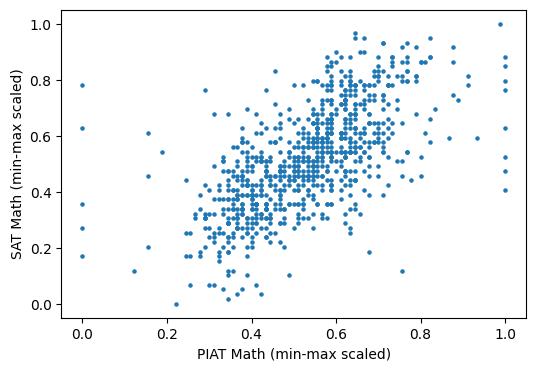

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(stud_piat_sat["piat_math_minmax"], stud_piat_sat["sat_math_minmax"], s=5)
ax.set_xlabel("PIAT Math (min-max scaled)")
ax.set_ylabel("SAT Math (min-max scaled)")
plt.show()

Again, we can rougly say that people who did well in PIAT Math are likely to do well on SAT Math.

But since the title is "correlation", let's investigate **Pearson correlation coefficient**, often just called **correlation**.

Before that we have to standardize both of the columns to standardize. Standard score of a sample X can be calculate with the below formula.

$$
Z = \frac{x - \bar{x}}{s}
$$

But we are going to use `StandardScaler` which also does the same thing for a dataset.

In [19]:
std_scaler = StandardScaler()
stud_piat_sat["piat_math_norm"] = std_scaler.fit_transform(stud_piat_sat[["piat_math"]])
stud_piat_sat["sat_math_norm"] = std_scaler.fit_transform(stud_piat_sat[["sat_math"]])
stud_piat_sat[["piat_math_norm", "sat_math_norm"]]

,piat_math_norm,sat_math_norm
0,3.118046,-0.584096
1,-0.720049,0.506958
2,0.313284,0.779721
3,-0.498620,1.688932
4,-1.901001,-0.402254
...,...,...
813,-0.867668,-1.675149
814,-1.679573,-1.766071
815,-0.129573,0.234194
816,-1.015287,-0.856859


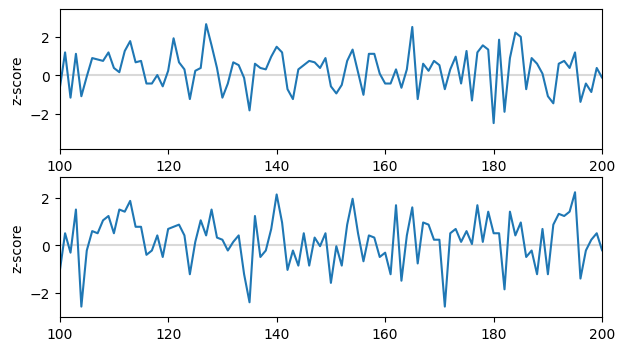

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(7, 4))
axes[0].axhline(y=0, color="black", alpha=0.15)
axes[1].axhline(y=0, color="black", alpha=0.15)
axes[0].plot(stud_piat_sat["piat_math_norm"])
axes[1].plot(stud_piat_sat["sat_math_norm"])
axes[0].set_xlim(100, 200)
axes[1].set_xlim(100, 200)
axes[0].set_ylabel("z-score")
axes[1].set_ylabel("z-score")
plt.show()

Even though it's hard to read it like this, we can totally see some kind of correlation here.

We can find the correlation coefficients using the below formula, and since we calculated the z-scores of our relevant columns, There is just one step left.

$$
r = \frac{\sum (z_x z_y)}{n-1}
$$

In [21]:
print("r =", np.mean(stud_piat_sat["piat_math_norm"] * stud_piat_sat["sat_math_norm"]))

r = 0.639735816517885


This means that, if someone's PIAT Math score is 1 standard deviation above the mean, we expect their SAT math score to be 0.64 standard deviations above the mean, on average. Since the correlation coefficient is symmetric, the opposite is also true.

In [22]:
print("r =", np.mean(stud_piat_sat["sat_math_norm"] * stud_piat_sat["piat_math_norm"]))

r = 0.639735816517885
